In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

import warnings
warnings.filterwarnings('ignore')

In [66]:
df = pd.read_csv('index.csv')

In [67]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


In [69]:
df.isnull().sum()

,0
date,0
datetime,0
cash_type,0
card,89
money,0
coffee_name,0


In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
#Convert date and datetime to datetme format
df['date']=pd.to_datetime(df['date'])
df['datetime']=pd.to_datetime(df['datetime'])
#Create column of Month, Weekdays, and Hours
df['month']=df['date'].dt.strftime('%Y-%m')
df['day']=df['date'].dt.strftime('%w')
df['hour']=df['datetime'].dt.strftime('%H')

In [72]:
[df['date'].min(),df['date'].max()]

[Timestamp('2024-03-01 00:00:00'), Timestamp('2024-07-31 00:00:00')]

In [73]:
df.shape

(1133, 9)

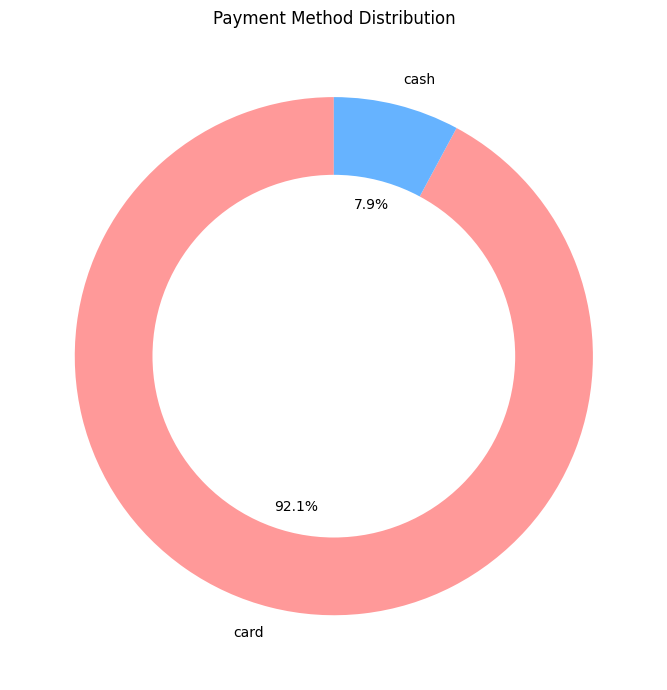

In [88]:
cash_type_dist = df['cash_type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(cash_type_dist, labels=cash_type_dist.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'], wedgeprops=dict(width=0.4))
plt.title('Payment Method Distribution')
plt.gca().add_artist(plt.Circle((0,0),0.70,fc='white'))
plt.tight_layout()
plt.show()

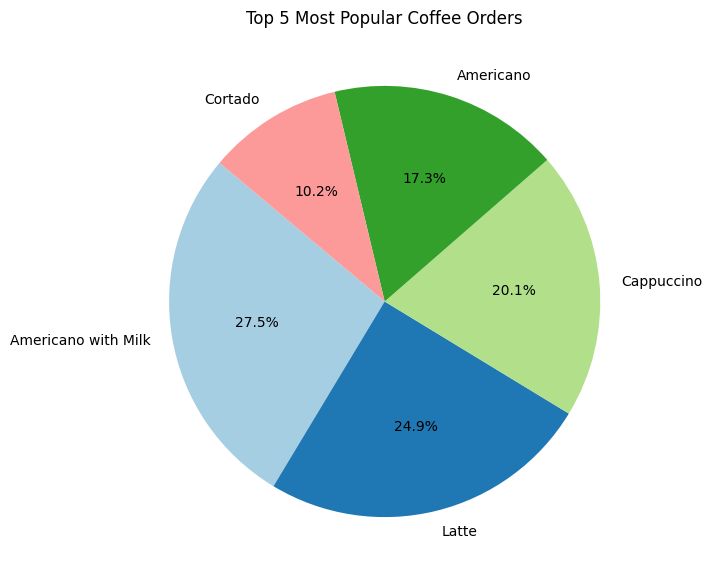

In [74]:
top_coffees = df['coffee_name'].value_counts().nlargest(5)

plt.figure(figsize=(7, 7))
top_coffees.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Top 5 Most Popular Coffee Orders')
plt.ylabel('')
plt.show()

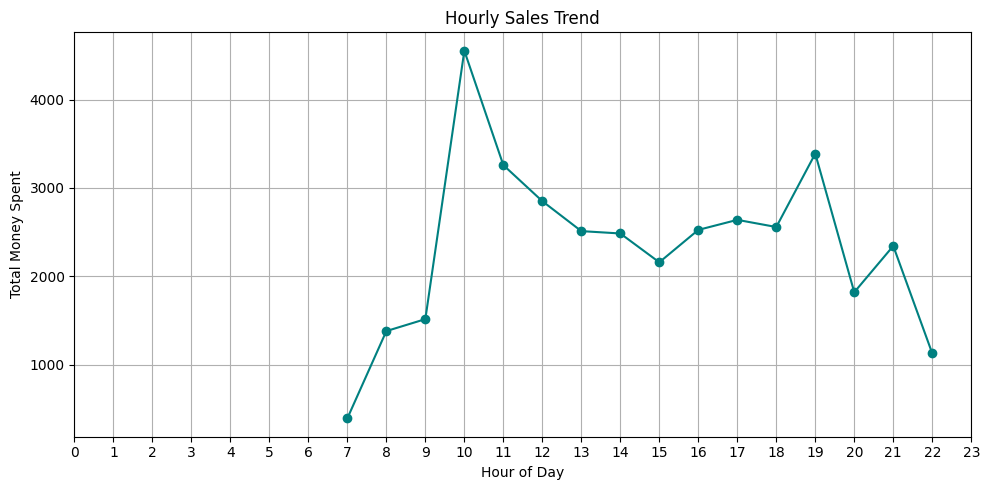

In [75]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour

hourly_sales = df.groupby('hour')['money'].sum()

plt.figure(figsize=(10, 5))
plt.plot(hourly_sales.index, hourly_sales.values, marker='o', linestyle='-', color='teal')
plt.title('Hourly Sales Trend')
plt.xlabel('Hour of Day')
plt.ylabel('Total Money Spent')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

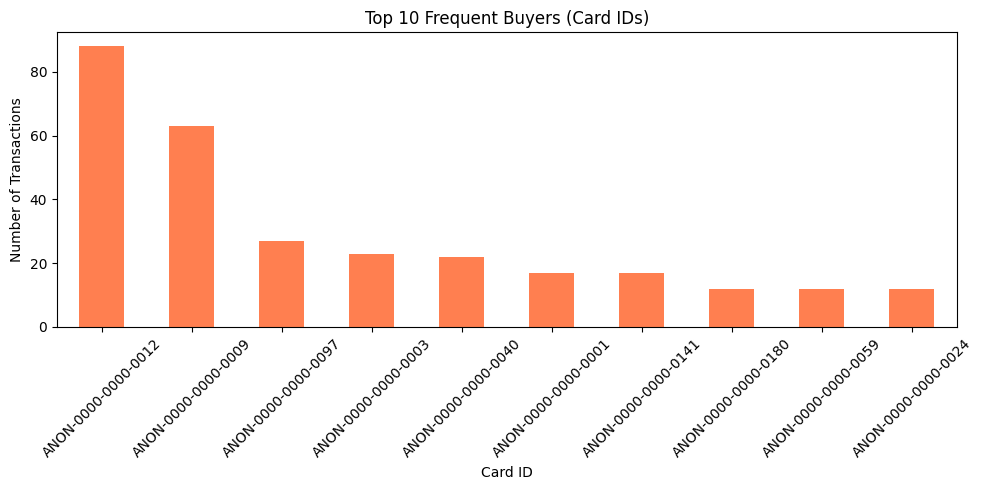

In [76]:
top_users = df['card'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_users.plot(kind='bar', color='coral')
plt.title('Top 10 Frequent Buyers (Card IDs)')
plt.ylabel('Number of Transactions')
plt.xlabel('Card ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

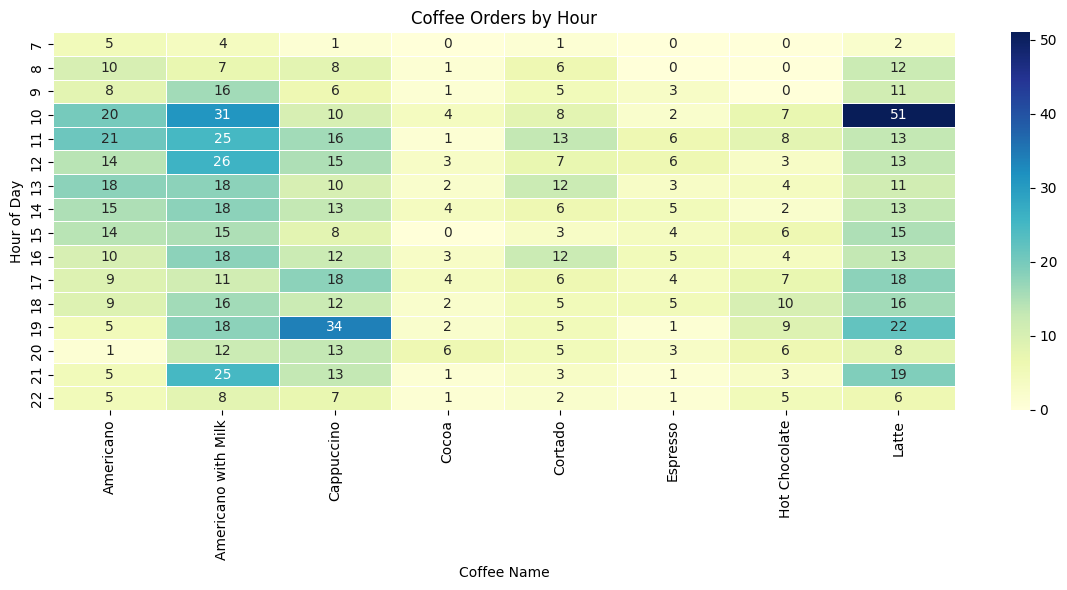

In [77]:
heatmap_data = df.groupby(['hour', 'coffee_name']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.5, annot=True, fmt='d')
plt.title('Coffee Orders by Hour')
plt.xlabel('Coffee Name')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

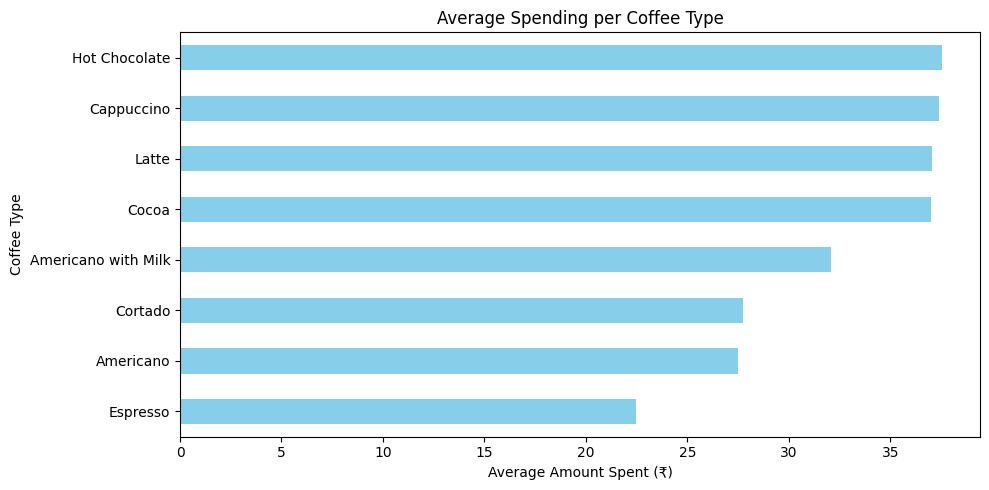

In [78]:
avg_spending = df.groupby('coffee_name')['money'].mean().sort_values()

plt.figure(figsize=(10, 5))
avg_spending.plot(kind='barh', color='skyblue')
plt.title('Average Spending per Coffee Type')
plt.xlabel('Average Amount Spent (₹)')
plt.ylabel('Coffee Type')
plt.tight_layout()
plt.show()

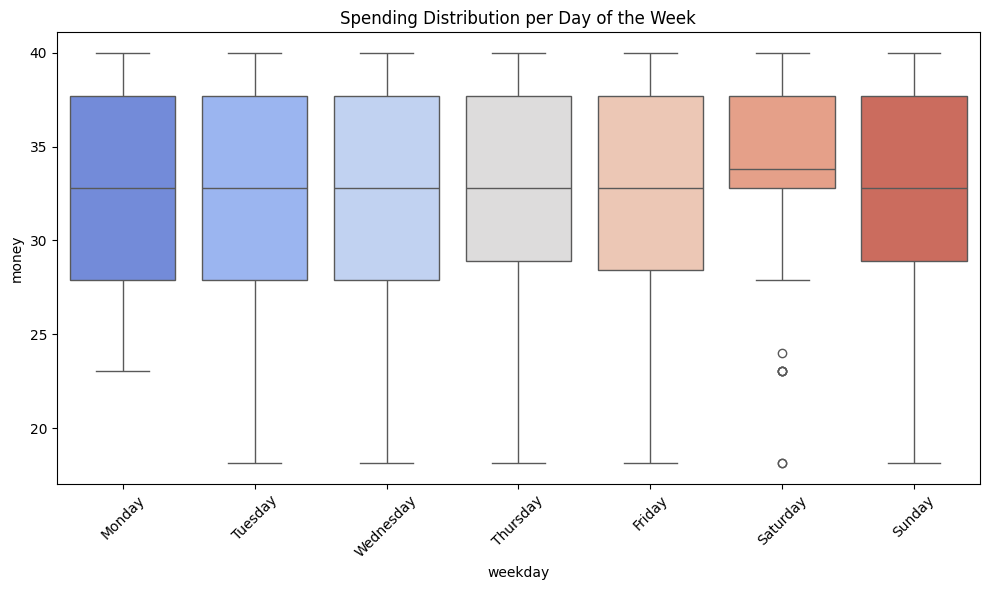

In [89]:
df['weekday'] = df['datetime'].dt.day_name()

plt.figure(figsize=(10, 6))
sns.boxplot(x='weekday', y='money', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='coolwarm')
plt.title('Spending Distribution per Day of the Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()